C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0083 - val_loss: 0.0126
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 8.7766e-04 - val_loss: 8.1986e-04
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 7.9946e-04 - val_loss: 6.9366e-04
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 6.0196e-04 - val_loss: 0.0011
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 5.0222e-04 - val_loss: 0.0015
Epoch 8/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 4.2809e-04 - val_loss: 0.0030
Epoch 9/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 3.9115e-04 - val_loss: 0.0019
Epoch 10/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 3.6498e-04 - val_loss: 6.0570e-04
Epoch 11/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 3.3869e-04 - val_loss: 2.96

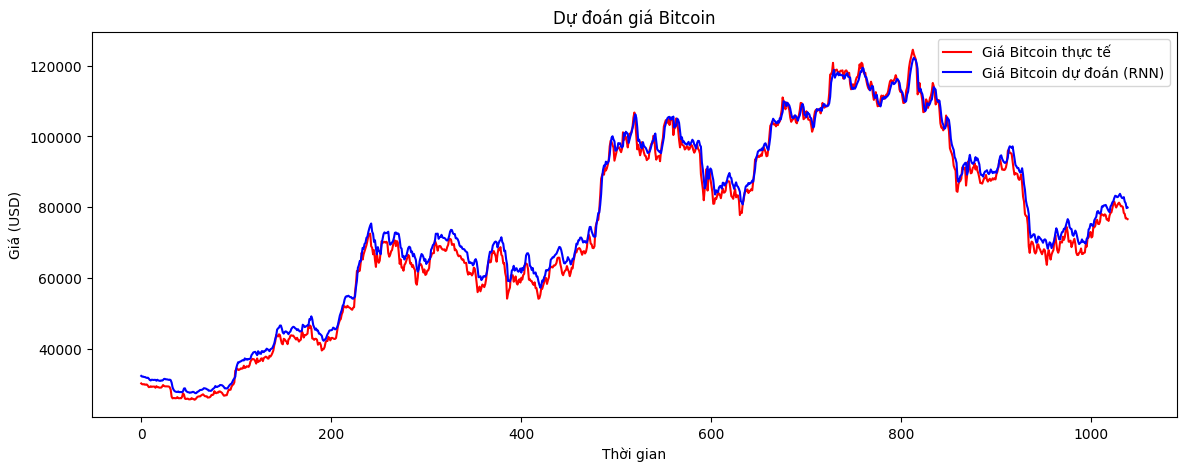

In [1]:
# Câu 2: Thiết kế và train model RNN dự báo giá Bitcoin
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# ---------------------------------------------------------
# BƯỚC 1: ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
# ---------------------------------------------------------
df = pd.read_csv('btcusd_1-min_data.csv')

# Chuyển cột Timestamp sang định dạng datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df.set_index('Timestamp', inplace=True)

# Resample dữ liệu từ phút sang ngày (lấy giá đóng cửa 'Close')
# Forward fill để điền các giá trị NaN nếu có ngày không có giao dịch
df_daily = df['Close'].resample('D').mean().ffill().values.reshape(-1, 1)

# Chuẩn hóa dữ liệu về khoảng [0, 1] để RNN hội tụ nhanh hơn
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_daily)

# ---------------------------------------------------------
# BƯỚC 2: TẠO DỮ LIỆU CHUỖI (SLIDING WINDOW)
# ---------------------------------------------------------
# Giả sử dùng giá Bitcoin của 60 ngày liên tiếp để dự đoán ngày thứ 61
window_size = 60 

X, y = [], []
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape X về định dạng 3D của Keras: [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Chia tập Train (80%) và Test (20%)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ---------------------------------------------------------
# BƯỚC 3: XÂY DỰNG MÔ HÌNH RNN
# ---------------------------------------------------------
model_rnn = Sequential()

# Lớp RNN đầu tiên với 50 nơ-ron
model_rnn.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_rnn.add(Dropout(0.2)) # Chống overfitting

# Lớp RNN thứ hai
model_rnn.add(SimpleRNN(units=50, return_sequences=False))
model_rnn.add(Dropout(0.2))

# Lớp Output dự đoán 1 giá trị
model_rnn.add(Dense(units=1))

model_rnn.compile(optimizer='adam', loss='mean_squared_error')
model_rnn.summary()

# ---------------------------------------------------------
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH
# ---------------------------------------------------------
history = model_rnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# ---------------------------------------------------------
# BƯỚC 5: TRỰC QUAN HÓA KẾT QUẢ TRÊN TẬP TEST
# ---------------------------------------------------------
predictions = model_rnn.predict(X_test)
predictions = scaler.inverse_transform(predictions) # Đưa về giá trị thực
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14,5))
plt.plot(y_test_real, color='red', label='Giá Bitcoin thực tế')
plt.plot(predictions, color='blue', label='Giá Bitcoin dự đoán (RNN)')
plt.title('Dự đoán giá Bitcoin')
plt.xlabel('Thời gian')
plt.ylabel('Giá (USD)')
plt.legend()
plt.show()

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 100)        │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,301 (317.58 KB)

 Trainable params: 81,301 (317.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 3.3767e-04 - val_loss: 0.0015
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 2.7727e-04 - val_loss: 6.1576e-04
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 2.8386e-04 - val_loss: 6.4614e-04
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 2.2456e-04 - val_loss: 0.0062
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 2.1038e-04 - val_loss: 7.3333e-04
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 2.5449e-04 - val_loss: 0.0010
Epoch 8/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 1.9371e-04 - val_loss: 8.7245e-04
Epoch 9/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 1.9531e-04 - val_loss: 0.0031
Epoch 10/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 1.9150e-04 - val_loss: 3.5194e-04
Epoch 11/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 1.9470e-0

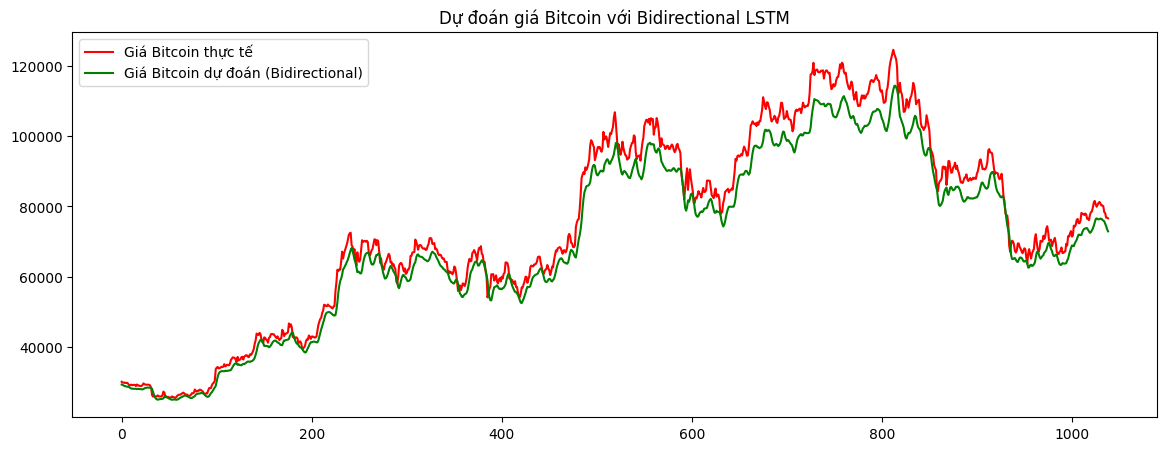

In [2]:
# Câu 3: Sử dụng mô hình Bidirectional cho bài toán trên
from tensorflow.keras.layers import Bidirectional, LSTM

# Xây dựng mô hình Bidirectional LSTM
model_bidi = Sequential()

# Lớp Bidirectional LSTM đầu tiên
# Lưu ý: return_sequences=True để truyền chuỗi cho lớp LSTM tiếp theo
model_bidi.add(Bidirectional(LSTM(units=50, return_sequences=True), input_shape=(X_train.shape[1], 1)))
model_bidi.add(Dropout(0.2))

# Lớp Bidirectional LSTM thứ hai
model_bidi.add(Bidirectional(LSTM(units=50, return_sequences=False)))
model_bidi.add(Dropout(0.2))

# Lớp Output
model_bidi.add(Dense(units=1))

model_bidi.compile(optimizer='adam', loss='mean_squared_error')
model_bidi.summary()

# Huấn luyện mô hình Bidirectional
history_bidi = model_bidi.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Dự đoán (Tương tự Bước 5 ở trên)
predictions_bidi = model_bidi.predict(X_test)
predictions_bidi = scaler.inverse_transform(predictions_bidi)

# Trực quan hóa
plt.figure(figsize=(14,5))
plt.plot(y_test_real, color='red', label='Giá Bitcoin thực tế')
plt.plot(predictions_bidi, color='green', label='Giá Bitcoin dự đoán (Bidirectional)')
plt.title('Dự đoán giá Bitcoin với Bidirectional LSTM')
plt.legend()
plt.show()